# 4주차 위클리 챌린지 5,6,7 번 노트북

## 5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.

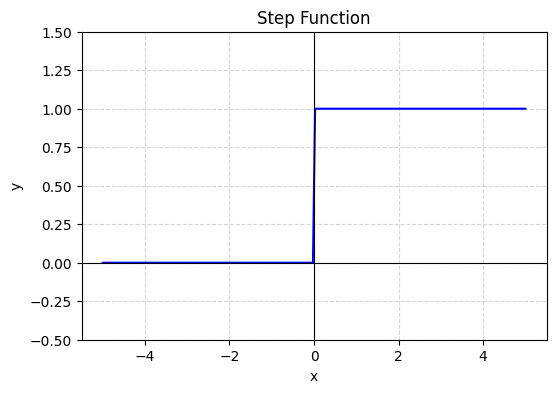

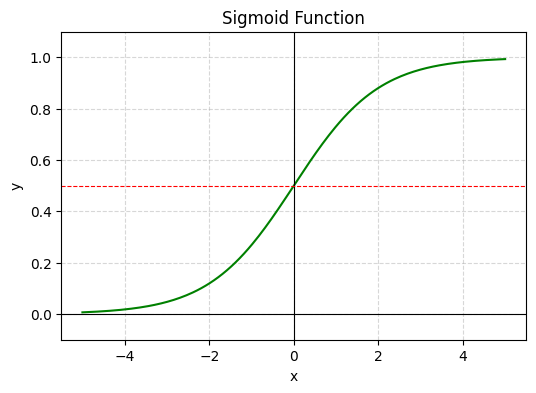

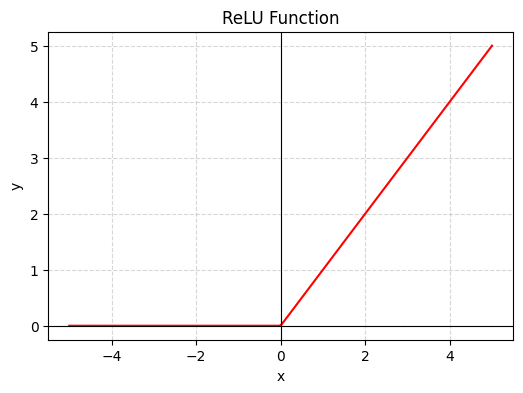

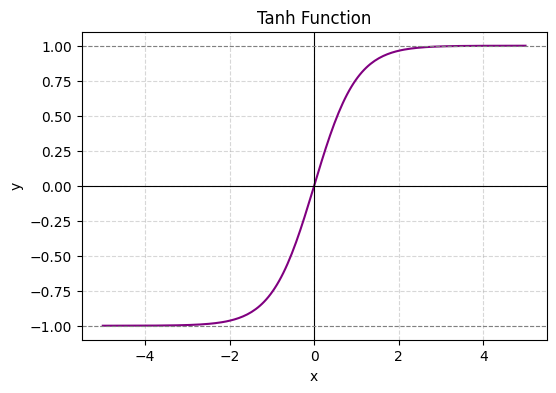

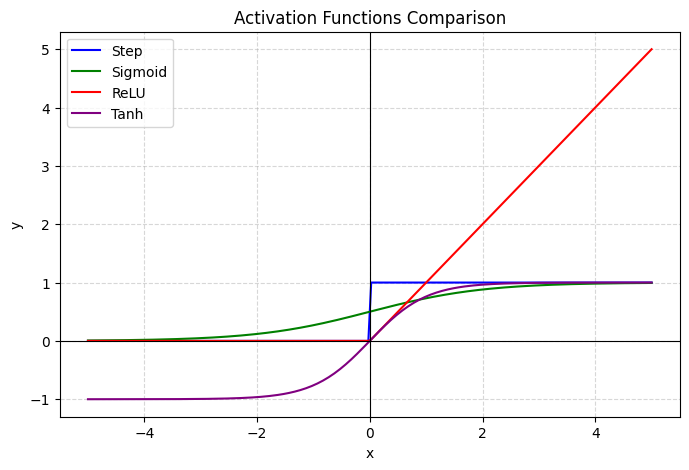

In [ ]:
# ============================================================
# 과제 5번 - 활성화 함수 직접 정의 및 시각화
# ============================================================
# 활성화 함수란?
# 뉴런이 w×x + b 를 계산한 결과를 그냥 출력하지 않고
# 한 번 더 변형시켜서 출력하는 함수다
# 이 변형 덕분에 신경망이 직선이 아닌 복잡한 곡선 경계를 학습할 수 있다
# 이번 과제에서는 라이브러리를 쓰지 않고 numpy로 직접 수식을 구현한다


import numpy as np                  # 수학 계산을 위한 라이브러리 (배열 연산, 지수함수 등)
import matplotlib.pyplot as plt     # 그래프 시각화를 위한 라이브러리


# ------------------------------------------------------------
# x 입력값 생성
# ------------------------------------------------------------
# 모든 활성화 함수는 같은 x 범위에서 계산하고 시각화한다
# np.linspace(시작, 끝, 개수): 시작~끝 사이를 균등하게 나눈 숫자 배열을 만든다
# -5 ~ 5 범위를 사용하는 이유: 활성화 함수의 특징(포화, 꺾임 등)이
# 이 범위 안에서 모두 나타나기 때문이다
x = np.linspace(-5, 5, 200)        # -5부터 5까지 200개의 숫자를 균등하게 생성
                                    # 숫자가 많을수록 그래프가 부드럽게 그려진다


# ============================================================
# 1. Step 함수
# ============================================================
# 수식: x > 0이면 1, x <= 0이면 0
# 퍼셉트론에서 사용하는 가장 단순한 활성화 함수다
# 입력값이 기준(0)을 넘으면 "켜짐(1)", 아니면 "꺼짐(0)"
# 단점: 미분하면 기울기가 항상 0이라 역전파(학습)에 사용할 수 없다

def step_function(x):               # x를 입력받아 Step 함수 결과를 반환하는 함수 정의
    return np.where(x > 0, 1, 0)   # np.where(조건, 참일때값, 거짓일때값)
                                    # x > 0 이면 1, 아니면 0을 반환
                                    # 배열 전체에 한 번에 적용된다 (반복문 불필요)

y_step = step_function(x)          # 생성한 x 배열 전체에 Step 함수를 적용해 y값 계산


plt.figure(figsize=(6, 4))         # 그래프 크기 설정 (가로 6인치, 세로 4인치)
plt.plot(x, y_step, color='blue')  # x축: 입력값, y축: Step 함수 출력값, 파란색 선
plt.title('Step Function')         # 그래프 제목
plt.xlabel('x')                    # x축 이름 (입력값)
plt.ylabel('y')                    # y축 이름 (출력값)
plt.axhline(0, color='black', linewidth=0.8)   # y=0 기준선 (가로 검정 실선)
                                               # axhline: 수평선 그리기
plt.axvline(0, color='black', linewidth=0.8)   # x=0 기준선 (세로 검정 실선)
                                               # axvline: 수직선 그리기
plt.grid(True, linestyle='--', alpha=0.5)      # 격자선 표시
                                               # linestyle='--': 점선
                                               # alpha=0.5: 격자선 투명도 50%
plt.ylim(-0.5, 1.5)               # y축 범위 설정: -0.5 ~ 1.5
                                   # 0과 1만 출력되는 함수라 여백을 주어 보기 좋게 함
plt.show()                         # 그래프를 화면에 출력


# ============================================================
# 2. Sigmoid 함수
# ============================================================
# 수식: 1 / (1 + e^(-x))
# 모든 입력값을 0~1 사이로 압축한다
# 출력값을 확률처럼 해석할 수 있어서 이진 분류의 출력층에 자주 쓴다
# 단점: x가 매우 크거나 작을 때 기울기가 거의 0이 됨 → 기울기 소실 문제
# 기울기 소실: 역전파 시 기울기가 0에 가까워져 학습이 멈추는 현상

def sigmoid(x):                     # x를 입력받아 Sigmoid 함수 결과를 반환하는 함수 정의
    return 1 / (1 + np.exp(-x))    # np.exp(-x): e^(-x) 계산 (e는 자연상수 약 2.718)
                                    # 수식 그대로 1 / (1 + e^-x) 를 구현한 것

y_sigmoid = sigmoid(x)             # x 배열 전체에 Sigmoid 함수를 적용해 y값 계산


plt.figure(figsize=(6, 4))                      # 그래프 크기 설정
plt.plot(x, y_sigmoid, color='green')           # Sigmoid 곡선, 초록색
plt.title('Sigmoid Function')                   # 그래프 제목
plt.xlabel('x')                                 # x축 이름
plt.ylabel('y')                                 # y축 이름
plt.axhline(0, color='black', linewidth=0.8)    # y=0 기준선
plt.axvline(0, color='black', linewidth=0.8)    # x=0 기준선
plt.axhline(0.5, color='red', linewidth=0.8, linestyle='--')   # y=0.5 기준선
                                                               # Sigmoid의 중심값(0.5)을
                                                               # 빨간 점선으로 표시
plt.grid(True, linestyle='--', alpha=0.5)       # 격자선
plt.ylim(-0.1, 1.1)                             # y축 범위: 0~1 출력에 여백 추가
plt.show()                                      # 그래프 출력


# ============================================================
# 3. ReLU 함수
# ============================================================
# 수식: max(0, x)
# x가 양수면 그대로 통과, 음수면 0으로 차단한다
# 현재 딥러닝에서 가장 많이 사용하는 활성화 함수다
# 이유: 계산이 단순하고, Sigmoid의 기울기 소실 문제가 거의 없다
# 양수 구간에서는 기울기가 항상 1이라 역전파가 막히지 않는다

def relu(x):                        # x를 입력받아 ReLU 함수 결과를 반환하는 함수 정의
    return np.maximum(0, x)        # np.maximum(0, x): 0과 x 중 더 큰 값을 반환
                                    # x가 양수면 x, 음수면 0이 선택된다
                                    # 배열 전체에 한 번에 적용된다

y_relu = relu(x)                   # x 배열 전체에 ReLU 함수를 적용해 y값 계산


plt.figure(figsize=(6, 4))                      # 그래프 크기 설정
plt.plot(x, y_relu, color='red')                # ReLU 선, 빨간색
plt.title('ReLU Function')                      # 그래프 제목
plt.xlabel('x')                                 # x축 이름
plt.ylabel('y')                                 # y축 이름
plt.axhline(0, color='black', linewidth=0.8)    # y=0 기준선
plt.axvline(0, color='black', linewidth=0.8)    # x=0 기준선
                                                # x=0 지점에서 꺾이는 것을 확인할 수 있다
plt.grid(True, linestyle='--', alpha=0.5)       # 격자선
plt.show()                                      # 그래프 출력


# ============================================================
# 4. Tanh 함수
# ============================================================
# 수식: (e^x - e^(-x)) / (e^x + e^(-x))
# 모든 입력값을 -1 ~ 1 사이로 압축한다
# Sigmoid와 모양이 비슷하지만 출력 중심이 0이다
# 중심이 0이면 학습이 더 안정적이다
# 이유: 출력값의 평균이 0에 가까워서 다음 층의 입력이 편향되지 않는다

def tanh(x):                                        # x를 입력받아 Tanh 함수 결과를 반환하는 함수 정의
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))   # 분자: e^x - e^(-x) / 분모: e^x + e^(-x)
                                                    # \ 는 코드를 다음 줄에 이어서 쓰는 기호
                                                    # 수식이 길어서 두 줄로 나눈 것

y_tanh = tanh(x)                                   # x 배열 전체에 Tanh 함수를 적용해 y값 계산


plt.figure(figsize=(6, 4))                          # 그래프 크기 설정
plt.plot(x, y_tanh, color='purple')                 # Tanh 곡선, 보라색
plt.title('Tanh Function')                          # 그래프 제목
plt.xlabel('x')                                     # x축 이름
plt.ylabel('y')                                     # y축 이름
plt.axhline(0, color='black', linewidth=0.8)        # y=0 기준선
plt.axvline(0, color='black', linewidth=0.8)        # x=0 기준선
plt.axhline(1, color='gray', linewidth=0.8, linestyle='--')    # y=1 상한선 (점선)
plt.axhline(-1, color='gray', linewidth=0.8, linestyle='--')   # y=-1 하한선 (점선)
                                                               # Tanh의 출력 범위가
                                                               # -1~1임을 시각적으로 표시
plt.grid(True, linestyle='--', alpha=0.5)           # 격자선
plt.show()                                          # 그래프 출력


# ============================================================
# 4가지 함수 한 그래프에 비교
# ============================================================
# 4개를 따로 보는 것도 중요하지만
# 같은 축에 겹쳐서 보면 출력 범위, 모양, 차이를 한눈에 비교할 수 있다

plt.figure(figsize=(8, 5))                          # 비교 그래프는 조금 더 크게 설정

plt.plot(x, y_step,    color='blue',   label='Step')     # Step 함수: 파란색
plt.plot(x, y_sigmoid, color='green',  label='Sigmoid')  # Sigmoid 함수: 초록색
plt.plot(x, y_relu,    color='red',    label='ReLU')     # ReLU 함수: 빨간색
plt.plot(x, y_tanh,    color='purple', label='Tanh')     # Tanh 함수: 보라색

plt.title('Activation Functions Comparison')        # 그래프 제목
plt.xlabel('x')                                     # x축 이름
plt.ylabel('y')                                     # y축 이름
plt.axhline(0, color='black', linewidth=0.8)        # y=0 기준선
plt.axvline(0, color='black', linewidth=0.8)        # x=0 기준선
plt.legend()                                        # 범례 표시: 어떤 선이 어떤 함수인지 표시
plt.grid(True, linestyle='--', alpha=0.5)           # 격자선
plt.show()                                          # 그래프 출력

## 6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.

In [ ]:
# ============================================================
# 셀 1: 라이브러리 import
# ============================================================

import torch                              # PyTorch 핵심 라이브러리
                                          # Tensor 생성, 연산, 자동 미분 등 모든 기능의 기반

import torch.nn as nn                     # 신경망 구성 도구 모음
                                          # nn.Linear(층), nn.ReLU(활성화함수) 등이 여기 있음

import torch.optim as optim               # 옵티마이저 모음
                                          # Adam, SGD 등 가중치 업데이트 알고리즘이 여기 있음

import numpy as np                        # 수치 계산 라이브러리
                                          # 데이터 생성, 배열 연산에 사용

from sklearn.datasets import make_moons   # 비선형 데이터 생성 함수
                                          # 반달 모양 두 클래스를 가진 2D 데이터를 만들어줌
                                          # MLP가 비선형 경계를 학습하는지 확인하기 좋은 데이터

from sklearn.model_selection import train_test_split  # 데이터 분할 함수
                                                      # 전체 데이터를 Train/Val/Test로 나눔

from sklearn.preprocessing import StandardScaler      # 정규화 도구
                                                      # 데이터를 평균 0, 표준편차 1로 변환

from sklearn.metrics import confusion_matrix          # 혼동 행렬 계산 함수
                                                      # TN, FP, FN, TP를 표로 보여줌

In [ ]:
# ============================================================
# 셀 2: 데이터 생성 및 확인
# ============================================================

X, y = make_moons(
    n_samples=1000,    # 전체 샘플 수 1000개
                       # 많을수록 모델이 더 잘 학습되지만 시간이 걸림
    noise=0.2,         # 노이즈(잡음) 정도
                       # 0이면 완벽한 반달 모양, 높을수록 점들이 흐트러짐
                       # 0.2 정도면 현실적인 데이터와 비슷한 난이도
    random_state=42    # 랜덤 시드 고정
                       # 같은 숫자를 쓰면 항상 같은 데이터가 생성됨
)

print("X shape:", X.shape)  # X shape: (1000, 2)
                             # 1000개 샘플, Feature 2개 (x좌표, y좌표)

print("y shape:", y.shape)  # y shape: (1000,)
                             # 1000개 샘플의 정답 (0 또는 1)

print("클래스 종류:", np.unique(y))  # [0, 1] 출력
                                     # 이진 분류 문제임을 확인

X shape: (1000, 2)
y shape: (1000,)
클래스 종류: [0 1]


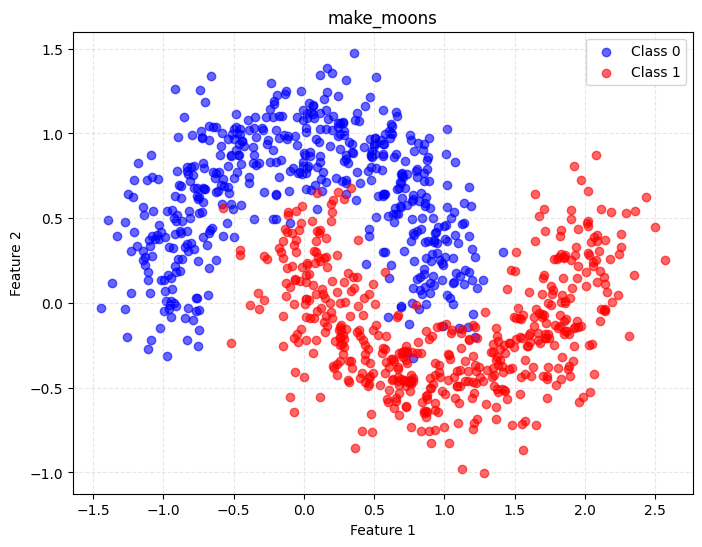

In [ ]:
# ============================================================
# 셀 2-1: 데이터 시각화
# ============================================================

import matplotlib.pyplot as plt         # 그래프 시각화 라이브러리

plt.figure(figsize=(8, 6))              # 그래프 크기 설정 (가로 8인치, 세로 6인치)

plt.scatter(
    X[y == 0, 0],                       # Class 0의 x좌표
                                        # y==0 인 행만 선택, 0번째 열(Feature1)
    X[y == 0, 1],                       # Class 0의 y좌표
                                        # y==0 인 행만 선택, 1번째 열(Feature2)
    color='blue',                       # Class 0은 파란색
    label='Class 0',                    # 범례 이름
    alpha=0.6                           # 투명도 60% (점이 겹쳐도 보이게)
)

plt.scatter(
    X[y == 1, 0],                       # Class 1의 x좌표
    X[y == 1, 1],                       # Class 1의 y좌표
    color='red',                        # Class 1은 빨간색
    label='Class 1',
    alpha=0.6
)

plt.title('make_moons')          # 그래프 제목
plt.xlabel('Feature 1')                 # x축 이름
plt.ylabel('Feature 2')                 # y축 이름
plt.legend()                            # 범례 표시 (Class 0, Class 1)
plt.grid(True, linestyle='--', alpha=0.3)  # 격자선
plt.show()                              # 그래프 출력

In [ ]:
# ============================================================
# 셀 3: 데이터 분할 + 정규화
# ============================================================

# --- 데이터 분할 ---
# 1차 분할: 전체 → Train(60%) / 나머지(40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,     # 40%를 나머지로 분리
    random_state=42    # 재현성을 위한 시드 고정
)

# 2차 분할: 나머지(40%) → Validation(20%) / Test(20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,     # 나머지의 절반 → 전체의 20%
    random_state=42
)

print("Train:", X_train.shape)      # (600, 2)
print("Validation:", X_val.shape)   # (200, 2)
print("Test:", X_test.shape)        # (200, 2)



# --- 정규화 전 ---
print("=" * 40)
print("정규화 전 (원본 데이터)")
print("=" * 40)

print(f"X_train 첫 5개:\n{X_train[:5]}")          # X가 아니라 X_train
print(f"Feature1 평균: {X_train[:, 0].mean():.4f}") # X_train 기준
print(f"Feature1 표준편차: {X_train[:, 0].std():.4f}")
print(f"Feature1 최솟값: {X_train[:, 0].min():.4f}")
print(f"Feature1 최댓값: {X_train[:, 0].max():.4f}")


# --- 정규화 ---
# 정규화가 필요한 이유:
# Feature 값의 범위가 크면 w 업데이트가 불안정해짐
# 평균 0, 표준편차 1로 맞추면 학습이 안정적이고 빨라짐

scaler = StandardScaler()                    # 정규화 도구 생성

X_train = scaler.fit_transform(X_train)      # Train으로 평균/표준편차 계산 후 변환
                                             # fit: 평균/표준편차 계산
                                             # transform: 실제 변환

X_val   = scaler.transform(X_val)           # Val은 transform만
                                             # Train 기준값 그대로 적용
                                             # fit을 다시 하면 데이터 누수 발생

X_test  = scaler.transform(X_test)          # Test도 transform만


# --- 정규화 후 ---
print("\n" + "=" * 40)
print("정규화 후 (StandardScaler 적용)")
print("=" * 40)
print(f"X_train 첫 5개:\n{X_train[:5]}")      # 정규화된 X_train 앞 5개 출력
                                              # 값들이 0 근처로 모여있어야 정상
print(f"\nFeature1 평균: {X_train[:, 0].mean():.4f}")   # 정규화 후 평균 → 거의 0
print(f"Feature1 표준편차: {X_train[:, 0].std():.4f}")  # 정규화 후 표준편차 → 거의 1
print(f"Feature1 최솟값: {X_train[:, 0].min():.4f}")    # 정규화 후 최솟값
print(f"Feature1 최댓값: {X_train[:, 0].max():.4f}")    # 정규화 후 최댓값

Train: (600, 2)
Validation: (200, 2)
Test: (200, 2)
정규화 전 (원본 데이터)
X_train 첫 5개:
[[ 0.02784978  0.80583708]
 [-0.96051246  0.32955679]
 [-0.9281753   0.5037756 ]
 [ 0.78030271  0.40337832]
 [ 2.29135997  0.52793238]]
Feature1 평균: 0.4766
Feature1 표준편차: 0.9093
Feature1 최솟값: -1.2589
Feature1 최댓값: 2.4954

정규화 후 (StandardScaler 적용)
X_train 첫 5개:
[[-0.49345972  1.06250031]
 [-1.5804114   0.17214462]
 [-1.5448486   0.4978283 ]
 [ 0.33405062  0.31014619]
 [ 1.9958363   0.54298685]]

Feature1 평균: -0.0000
Feature1 표준편차: 1.0000
Feature1 최솟값: -1.9085
Feature1 최댓값: 2.2202


In [ ]:
# ============================================================
# 셀 4: Tensor 변환
# ============================================================
# PyTorch는 numpy 배열을 직접 받지 않는다
# 반드시 PyTorch Tensor 형태로 변환해야 한다
# Tensor = PyTorch가 다루는 데이터 형태 (numpy 배열과 비슷하지만 자동 미분 지원)

X_train_t = torch.FloatTensor(X_train)       # numpy → FloatTensor (실수형 Tensor)
                                             # FloatTensor: 32비트 실수
                                             # 딥러닝에서 기본으로 사용하는 데이터 타입

X_val_t   = torch.FloatTensor(X_val)
X_test_t  = torch.FloatTensor(X_test)

y_train_t = torch.FloatTensor(y_train).unsqueeze(1)  # (600,) → (600, 1) 로 변환
                                                      # unsqueeze(1): 차원을 1개 추가
                                                      # 이유: 모델 출력이 (600, 1) 형태라서
                                                      # y도 같은 형태로 맞춰줘야 손실 계산 가능

y_val_t   = torch.FloatTensor(y_val).unsqueeze(1)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

print("X_train_t shape:", X_train_t.shape)  # torch.Size([600, 2])
print("y_train_t shape:", y_train_t.shape)  # torch.Size([600, 1])

X_train_t shape: torch.Size([600, 2])
y_train_t shape: torch.Size([600, 1])


In [ ]:
# ============================================================
# 셀 5: 모델 설계
# ============================================================
# MLP = Multi-Layer Perceptron = 다층 퍼셉트론
# 입력층 → 은닉층 → 은닉층 → 출력층 구조로 설계한다
# nn.Module을 상속받아 클래스로 설계하는 것이 PyTorch의 표준 방식
# 상속: 부모 클래스(nn.Module)의 기능을 그대로 가져와서 사용한다는 뜻

class MLP(nn.Module):                        # nn.Module을 상속받아 MLP 설계도 작성

    def __init__(self):                      # 모델이 처음 만들어질 때 실행되는 함수
                                             # 여기서 층 구조를 정의한다
        super().__init__()                   # 부모 클래스(nn.Module) 초기화
                                             # 반드시 써야 PyTorch 기능이 정상 작동함

        self.layer1 = nn.Linear(2, 16)       # 입력층 → 은닉층1
                                             # nn.Linear(입력 수, 출력 수)
                                             # 입력 Feature 2개 → 뉴런 16개
                                             # 내부적으로 w(2×16=32개)와 b(16개) 자동 생성

        self.layer2 = nn.Linear(16, 8)       # 은닉층1 → 은닉층2
                                             # 뉴런 16개 → 뉴런 8개

        self.layer3 = nn.Linear(8, 1)        # 은닉층2 → 출력층
                                             # 뉴런 8개 → 출력 1개
                                             # 이진 분류라서 출력이 1개 (0 또는 1 확률)

        self.relu    = nn.ReLU()             # 은닉층 활성화 함수
                                             # 양수는 그대로, 음수는 0으로 차단

        self.sigmoid = nn.Sigmoid()          # 출력층 활성화 함수
                                             # 출력값을 0~1 사이 확률로 변환
                                             # 0.5 이상이면 클래스 1, 미만이면 클래스 0

    def forward(self, x):                    # 순전파 경로 정의
                                             # 데이터가 모델 안에서 어떻게 흘러가는지 정의
                                             # model(x) 호출 시 자동으로 실행됨

        x = self.relu(self.layer1(x))        # 입력 → 층1 계산(w×x+b) → ReLU
        x = self.relu(self.layer2(x))        # → 층2 계산 → ReLU
        x = self.sigmoid(self.layer3(x))     # → 층3 계산 → Sigmoid → 확률 출력
        return x                             # 최종 예측값 반환 (0~1 사이 확률)


model = MLP()                                # 설계도(클래스)로 실제 모델 생성
                                             # 이 시점에 w들이 랜덤으로 초기화됨

print(model)                                 # 모델 구조 출력
                                             # 층 이름, 입출력 크기 확인 가능

MLP(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [ ]:
# ============================================================
# 셀 6: Loss 함수 + Optimizer 설정
# ============================================================

criterion = nn.BCELoss()
# BCE = Binary Cross Entropy (이진 교차 엔트로피)
# 이진 분류에서 표준으로 사용하는 손실 함수
# 예측값과 정답의 차이를 계산하는 방식이 MSE보다 이진 분류에 더 적합
# 예측값이 정답에 가까울수록 손실이 0에 가까워짐
# 예측값이 정답과 멀수록 손실이 크게 증가함

optimizer = optim.Adam(
    model.parameters(),  # 모델 안의 모든 w와 b를 가리킴
                         # 이 w들을 Adam이 업데이트할 대상으로 등록
    lr=0.001             # 학습률 (Learning Rate)
                         # 한 번에 w를 얼마나 크게 바꿀지 결정
                         # 0.001은 Adam의 기본값이자 가장 많이 쓰는 값
)

In [ ]:
# ============================================================
# 셀 7: 학습 루프
# ============================================================
# 순전파 → 손실 계산 → 역전파 → 가중치 업데이트를 반복한다
# 이 반복 한 번을 Epoch(에포크)라고 한다
# Epoch = 전체 데이터를 한 바퀴 학습하는 단위

epochs = 1000            # 전체 데이터를 1000번 반복 학습
                         # 숫자가 클수록 더 많이 학습하지만 시간이 걸림
                         # 너무 많으면 과적합(Train만 잘 맞추고 Test는 못 맞춤) 발생 가능

for epoch in range(epochs):             # 0부터 999까지 1000번 반복

    # --- 학습 모드 ---
    model.train()                        # 모델을 학습 모드로 설정
                                         # 학습 중에만 동작하는 기능들을 활성화
                                         # (지금은 크게 신경 안 써도 됨. 습관적으로 쓰는 것)

    # 1. 순전파
    pred = model(X_train_t)              # 모델에 Train 데이터 입력 → 예측값 계산
                                         # forward() 함수가 자동으로 실행됨
                                         # pred: (600, 1) 형태의 확률값

    # 2. 손실 계산
    loss = criterion(pred, y_train_t)    # 예측값과 정답을 비교해서 손실 계산
                                         # 손실이 클수록 예측이 틀린 것

    # 3. 기울기 초기화
    optimizer.zero_grad()                # 이전 epoch에서 계산된 기울기를 0으로 초기화
                                         # PyTorch는 기울기를 누적하는 방식이라
                                         # 초기화 안 하면 이전 기울기가 더해져서 엉뚱한 방향으로 업데이트됨
                                         # 반드시 backward() 전에 호출해야 함

    # 4. 역전파
    loss.backward()                      # 손실을 기반으로 모든 w의 기울기 자동 계산
                                         # 연쇄 법칙(Chain Rule)으로 출력층 → 입력층 방향으로 계산
                                         # 우리가 직접 미분할 필요 없음

    # 5. 가중치 업데이트
    optimizer.step()                     # 계산된 기울기로 모든 w를 업데이트
                                         # Adam 방식으로 w마다 학습률을 자동 조절해서 업데이트

    # --- 100 epoch마다 진행 상황 출력 ---
    if (epoch + 1) % 100 == 0:          # epoch가 100, 200, 300... 일 때만 출력
        model.eval()                     # 평가 모드로 전환
                                         # 평가할 때는 기울기 계산이 필요 없음

        with torch.no_grad():            # 기울기 계산 비활성화
                                         # 평가 시에는 역전파가 필요 없어서
                                         # 기울기 계산을 끄면 메모리와 속도가 절약됨

            val_pred = model(X_val_t)                        # Validation 데이터로 예측
            val_loss = criterion(val_pred, y_val_t)          # Validation 손실 계산
            val_acc  = ((val_pred >= 0.5) == y_val_t).float().mean().item()
            # val_pred >= 0.5: 확률이 0.5 이상이면 True(1), 미만이면 False(0)
            # == y_val_t: 정답과 비교
            # .float(): True/False → 1.0/0.0 으로 변환
            # .mean(): 전체 평균 → 정확도
            # .item(): Tensor → 일반 숫자로 변환

        print(f"Epoch {epoch+1:4d} | "
              f"Train Loss: {loss.item():.4f} | "
              f"Val Loss: {val_loss.item():.4f} | "
              f"Val Acc: {val_acc*100:.2f}%")
        # loss.item(): Tensor 손실값을 일반 숫자로 변환
        # :.4f: 소수점 4자리까지 출력

Epoch  100 | Train Loss: 0.4709 | Val Loss: 0.4762 | Val Acc: 83.00%
Epoch  200 | Train Loss: 0.3216 | Val Loss: 0.3293 | Val Acc: 85.50%
Epoch  300 | Train Loss: 0.2618 | Val Loss: 0.2632 | Val Acc: 90.00%
Epoch  400 | Train Loss: 0.2262 | Val Loss: 0.2228 | Val Acc: 92.00%
Epoch  500 | Train Loss: 0.1828 | Val Loss: 0.1766 | Val Acc: 93.50%
Epoch  600 | Train Loss: 0.1425 | Val Loss: 0.1334 | Val Acc: 96.00%
Epoch  700 | Train Loss: 0.1132 | Val Loss: 0.1030 | Val Acc: 96.50%
Epoch  800 | Train Loss: 0.0927 | Val Loss: 0.0833 | Val Acc: 97.50%
Epoch  900 | Train Loss: 0.0782 | Val Loss: 0.0719 | Val Acc: 97.50%
Epoch 1000 | Train Loss: 0.0683 | Val Loss: 0.0673 | Val Acc: 97.50%


In [ ]:
# ============================================================
# 셀 8: 최종 평가
# ============================================================

model.eval()                             # 평가 모드로 전환

with torch.no_grad():                    # 기울기 계산 비활성화 (평가라서 필요 없음)

    # Train 정확도
    train_pred = model(X_train_t)
    train_acc  = ((train_pred >= 0.5) == y_train_t).float().mean().item()

    # Validation 정확도
    val_pred = model(X_val_t)
    val_acc  = ((val_pred >= 0.5) == y_val_t).float().mean().item()

    # Test 정확도
    test_pred  = model(X_test_t)
    test_acc   = ((test_pred >= 0.5) == y_test_t).float().mean().item()

print("=" * 40)
print(f"Train      정확도: {train_acc*100:.2f}%")
print(f"Validation 정확도: {val_acc*100:.2f}%")
print(f"Test       정확도: {test_acc*100:.2f}%")
print("=" * 40)

# 혼동 행렬
# test_pred를 numpy로 변환해서 혼동 행렬 계산
y_pred_class = (test_pred >= 0.5).int().numpy()
# >= 0.5: 0.5 이상이면 1, 미만이면 0 으로 변환
# .int(): True/False → 1/0 정수로 변환
# .numpy(): Tensor → numpy 배열로 변환 (confusion_matrix가 numpy를 받음)

cm = confusion_matrix(y_test, y_pred_class)  # 정답(y_test)과 예측값 비교

print("\n혼동 행렬 (Test 기준)")
print(f"TN: {cm[0][0]}  FP: {cm[0][1]}")
print(f"FN: {cm[1][0]}  TP: {cm[1][1]}")
# TN: 0을 0으로 맞춤 (정답)
# FP: 0을 1로 틀림 (오예측)
# FN: 1을 0으로 틀림 (오예측)
# TP: 1을 1로 맞춤 (정답)

Train      정확도: 98.17%
Validation 정확도: 97.50%
Test       정확도: 97.00%

혼동 행렬 (Test 기준)
TN: 91  FP: 3
FN: 3  TP: 103


## 7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.

In [ ]:
# ============================================================
# 셀 1: 라이브러리 import
# ============================================================

import torch                               # PyTorch 핵심 라이브러리
import torch.nn as nn                      # 신경망 구성 도구
import torch.optim as optim                # 옵티마이저

from torchvision import datasets, transforms   # torchvision: 이미지 관련 라이브러리
                                               # datasets: MNIST 등 유명 데이터셋 제공
                                               # transforms: 이미지 전처리 도구

from torch.utils.data import DataLoader    # 데이터를 배치 단위로 나눠서 모델에 공급하는 도구
                                           # 배치: 전체 데이터를 작은 묶음으로 나눈 것

from sklearn.metrics import confusion_matrix   # 혼동 행렬
import numpy as np

In [ ]:
# ============================================================
# 셀 2: 데이터 로드 및 확인
# ============================================================

# --- 전처리 정의 ---
transform = transforms.Compose([
    transforms.ToTensor(),              # 이미지를 Tensor로 변환
                                        # 픽셀값 0~255 → 0~1 사이로 자동 변환 (정규화)
                                        # 형태: (28, 28) → (1, 28, 28)
                                        # 1: 채널 수 (흑백이라 1개, 컬러면 3개)

    transforms.Normalize((0.5,), (0.5,))  # 평균 0.5, 표준편차 0.5로 정규화
                                           # 0~1 범위 → -1~1 범위로 변환
                                           # 학습이 더 안정적이 됨
])

# --- 데이터 로드 ---
train_dataset = datasets.MNIST(
    root='./data',          # 데이터를 저장할 폴더 경로
    train=True,             # True: 학습용 데이터 (60,000개)
    download=True,          # 데이터가 없으면 자동으로 다운로드
    transform=transform     # 위에서 정의한 전처리 적용
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,            # False: 테스트용 데이터 (10,000개)
    download=True,
    transform=transform
)

# --- 데이터 확인 ---
print(f"Train 데이터 수: {len(train_dataset)}")    # 60000
print(f"Test 데이터 수: {len(test_dataset)}")      # 10000

image, label = train_dataset[0]                    # 첫 번째 샘플 꺼내기
print(f"\n이미지 형태: {image.shape}")              # torch.Size([1, 28, 28])
                                                   # 1: 채널 (흑백)
                                                   # 28×28: 픽셀
print(f"정답 레이블: {label}")                      # 0~9 중 하나
print(f"픽셀값 범위: {image.min():.2f} ~ {image.max():.2f}")  # -1 ~ 1

100%|██████████| 9.91M/9.91M [00:00<00:00, 137MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 16.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 156MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.92MB/s]


Train 데이터 수: 60000
Test 데이터 수: 10000

이미지 형태: torch.Size([1, 28, 28])
정답 레이블: 5
픽셀값 범위: -1.00 ~ 1.00


In [ ]:
# ============================================================
# 셀 3: DataLoader 설정
# ============================================================
# DataLoader가 필요한 이유:
# MNIST Train 데이터가 60,000개
# 60,000개를 한 번에 모델에 넣으면 메모리가 부족할 수 있음
# 배치(batch) 단위로 나눠서 조금씩 넣는 것이 효율적

# 배치(batch)란?
# 전체 데이터를 작은 묶음으로 나눈 것
# batch_size=64 이면 64개씩 묶어서 모델에 넣음
# 60,000 / 64 = 약 937번 반복하면 전체 데이터를 한 바퀴 돔 (= 1 Epoch)

train_loader = DataLoader(
    train_dataset,          # 학습 데이터셋
    batch_size=64,          # 한 번에 64개씩 묶어서 처리
                            # 너무 크면 메모리 부족
                            # 너무 작으면 학습이 불안정
                            # 32, 64, 128이 많이 쓰임
    shuffle=True            # 매 Epoch마다 데이터 순서를 섞음
                            # 섞지 않으면 항상 같은 순서로 학습해서 편향될 수 있음
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False           # 테스트는 순서 섞을 필요 없음
                            # 평가할 때는 항상 같은 순서로 보는 게 일관성 있음
)

print(f"Train 배치 수: {len(train_loader)}")    # 60000 / 64 = 938
print(f"Test 배치 수: {len(test_loader)}")      # 10000 / 64 = 157

Train 배치 수: 938
Test 배치 수: 157


In [ ]:
# ============================================================
# 셀 4: CNN 모델 설계
# ============================================================
# CNN 구조:
# Conv층 → ReLU → Pooling → Conv층 → ReLU → Pooling
# → Flatten → Linear → Linear → 출력

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # --- Conv층 1 ---
        self.conv1 = nn.Conv2d(
            in_channels=1,      # 입력 채널 수
                                # 흑백 이미지라서 1
                                # 컬러(RGB)면 3
            out_channels=32,    # 필터 수 = 출력 채널 수
                                # 필터 32개로 32가지 특징을 추출
            kernel_size=3,      # 필터 크기 3×3
                                # 이미지를 3×3 구역씩 훑음
            padding=1           # 이미지 테두리에 0을 추가
                                # 입력과 출력 크기를 같게 유지하기 위함
                                # padding=1이면 28×28 → 28×28 유지
        )
        # conv1 후 이미지 크기: (1, 28, 28) → (32, 28, 28)

        # --- Pooling층 1 ---
        self.pool = nn.MaxPool2d(
            kernel_size=2,      # 2×2 구역에서 최댓값만 뽑음
            stride=2            # 2칸씩 이동
                                # 이미지 크기가 절반으로 줄어듦
                                # 28×28 → 14×14
        )
        # pool 후 이미지 크기: (32, 28, 28) → (32, 14, 14)

        # --- Conv층 2 ---
        self.conv2 = nn.Conv2d(
            in_channels=32,     # conv1의 출력 채널 수와 같아야 함
            out_channels=64,    # 필터 64개로 더 복잡한 특징 추출
            kernel_size=3,
            padding=1
        )
        # conv2 후 이미지 크기: (32, 14, 14) → (64, 14, 14)
        # pool 후 이미지 크기: (64, 14, 14) → (64, 7, 7)

        self.relu = nn.ReLU()   # 활성화 함수

        # --- Flatten ---
        # Conv층을 거친 2D 특징 맵을 1D로 펼쳐야 Linear층에 넣을 수 있음
        # 64 × 7 × 7 = 3136개로 펼쳐짐

        # --- Linear층 ---
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 3136 → 128
                                                 # fc = fully connected
                                                 # 모든 뉴런이 연결된 층
                                                 # MLP의 Linear층과 동일

        self.fc2 = nn.Linear(128, 10)           # 128 → 10
                                                 # 출력이 10개인 이유:
                                                 # 숫자 0~9, 총 10개 클래스

    def forward(self, x):                        # 순전파 경로 정의

        x = self.relu(self.conv1(x))             # Conv1 → ReLU
        x = self.pool(x)                         # Pooling → 28×28 → 14×14

        x = self.relu(self.conv2(x))             # Conv2 → ReLU
        x = self.pool(x)                         # Pooling → 14×14 → 7×7

        x = x.view(-1, 64 * 7 * 7)              # Flatten: 2D → 1D
                                                 # x.view(-1, 3136)
                                                 # -1: 배치 크기는 자동으로 맞춤
                                                 # 64×7×7=3136개로 펼침

        x = self.relu(self.fc1(x))               # Linear1 → ReLU
        x = self.fc2(x)                          # Linear2 → 출력 10개
                                                 # 출력층에 활성화 함수 없음
                                                 # CrossEntropyLoss가 내부적으로 처리

        return x


torch.manual_seed(42)                           # 재현성을 위한 시드 고정
model = CNN()                                   # 모델 생성
print(model)                                    # 모델 구조 출력

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# ============================================================
# 셀 5: Loss 함수 + Optimizer 설정
# ============================================================

criterion = nn.CrossEntropyLoss()   # 다중 분류용 손실 함수
                                    # 6번에서 BCELoss를 쓴 것과 다름
                                    # BCELoss: 이진 분류 (0 또는 1)
                                    # CrossEntropyLoss: 다중 분류 (0~9)
                                    # 내부적으로 Softmax를 포함하고 있음
                                    # 그래서 출력층에 Softmax를 따로 안 붙임

optimizer = optim.Adam(
    model.parameters(),             # 모델의 모든 w, b
    lr=0.001                        # 학습률
)

In [ ]:
# ============================================================
# 셀 6: 학습 루프
# ============================================================

epochs = 5                          # 5번 반복
                                    # MNIST는 데이터가 60,000개라
                                    # 5번만 해도 충분히 학습됨
                                    # 1번에 약 938 배치 처리

for epoch in range(epochs):

    model.train()                   # 학습 모드
    total_loss = 0                  # epoch당 전체 손실 누적용
    correct = 0                     # 맞춘 개수
    total = 0                       # 전체 개수

    for images, labels in train_loader:     # 배치 단위로 데이터를 꺼냄
                                            # images: (64, 1, 28, 28)
                                            # labels: (64,)

        # 1. 순전파
        pred = model(images)                # 예측값 계산
                                            # 출력 형태: (64, 10)
                                            # 64개 샘플, 각각 10개 클래스 점수

        # 2. 손실 계산
        loss = criterion(pred, labels)      # CrossEntropyLoss로 손실 계산

        # 3. 기울기 초기화
        optimizer.zero_grad()

        # 4. 역전파
        loss.backward()

        # 5. 가중치 업데이트
        optimizer.step()

        # 통계 누적
        total_loss += loss.item()           # 배치 손실 누적
        predicted = pred.argmax(dim=1)      # 10개 중 가장 큰 값의 인덱스
                                            # argmax: 가장 큰 값의 위치 반환
                                            # 예) [0.1, 0.8, 0.05, ...] → 1 (숫자 1로 예측)
        correct += (predicted == labels).sum().item()   # 맞춘 개수 누적
        total += labels.size(0)             # 전체 개수 누적

    train_acc = correct / total             # epoch당 Train 정확도
    avg_loss = total_loss / len(train_loader)  # epoch당 평균 손실

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}%")

Epoch 1/5 | Loss: 0.1692 | Train Acc: 94.84%
Epoch 2/5 | Loss: 0.0485 | Train Acc: 98.52%
Epoch 3/5 | Loss: 0.0334 | Train Acc: 98.99%
Epoch 4/5 | Loss: 0.0239 | Train Acc: 99.23%
Epoch 5/5 | Loss: 0.0189 | Train Acc: 99.40%


In [ ]:
# ============================================================
# 셀 7: 최종 평가
# ============================================================

model.eval()
correct = 0
total = 0
all_preds = []      # 전체 예측값 저장 (혼동 행렬용)
all_labels = []     # 전체 정답 저장 (혼동 행렬용)

with torch.no_grad():                           # 기울기 계산 비활성화

    for images, labels in test_loader:          # 테스트 배치 단위로 처리

        pred = model(images)                    # 예측
        predicted = pred.argmax(dim=1)          # 가장 높은 점수 클래스 선택

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.numpy())     # 배치 예측값을 리스트에 추가
        all_labels.extend(labels.numpy())       # 배치 정답을 리스트에 추가

test_acc = correct / total
print(f"Test 정확도: {test_acc*100:.2f}%")

# 혼동 행렬
cm = confusion_matrix(all_labels, all_preds)
print("\n혼동 행렬 (Test 기준)")
print(cm)                                       # 10×10 행렬로 출력
                                                # 행: 실제 정답 (0~9)
                                                # 열: 예측값 (0~9)
                                                # 대각선: 맞춘 것
                                                # 대각선 외: 틀린 것

Test 정확도: 98.87%

혼동 행렬 (Test 기준)
[[ 976    0    0    1    0    0    2    0    1    0]
 [   0 1129    0    3    0    1    2    0    0    0]
 [   1    0 1017    2    2    0    0    8    2    0]
 [   0    0    1 1007    0    1    0    0    1    0]
 [   0    1    0    0  966    0    2    0    2   11]
 [   1    0    0   20    0  867    1    0    1    2]
 [   3    2    0    0    1    4  944    0    4    0]
 [   0    1    2    2    0    0    0 1022    1    0]
 [   0    1    1    2    0    1    0    3  965    1]
 [   1    0    0    2    2    2    0    6    2  994]]
